## Explainability

In [1]:
import shap
import numpy as np
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-11 16:30:09.475110: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 16:30:09.516143: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 16:30:10.565545: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may se

In [2]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [3]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
X_test_scaled = np.load(os.path.join(ARTIFACT_DIR,"X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR,"y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR,"encoder.pkl"))
feature_names = joblib.load(os.path.join(ARTIFACT_DIR,"feature_names.pkl"))
background = np.load(os.path.join(ARTIFACT_DIR,"shap_background.npy"))

2026-03-11 16:30:10.714402: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### SHAP

In [4]:
sample_size = 50
idx = np.random.choice(len(X_test_scaled), sample_size, replace = False)
X_sample = X_test_scaled[idx]

In [5]:
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_sample)

/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 45))']
  warnings.warn(msg)
/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(400, 45))']
  warnings.warn(msg)
/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `in

In [6]:
print(f"Model output shape: {model.output_shape}")
print(f"Number of SHAP arrays: {len(shap_values)}")
print(f"Number of labels: {len(encoder.classes_)}")

Model output shape: (None, 5)
Number of SHAP arrays: 50
Number of labels: 5


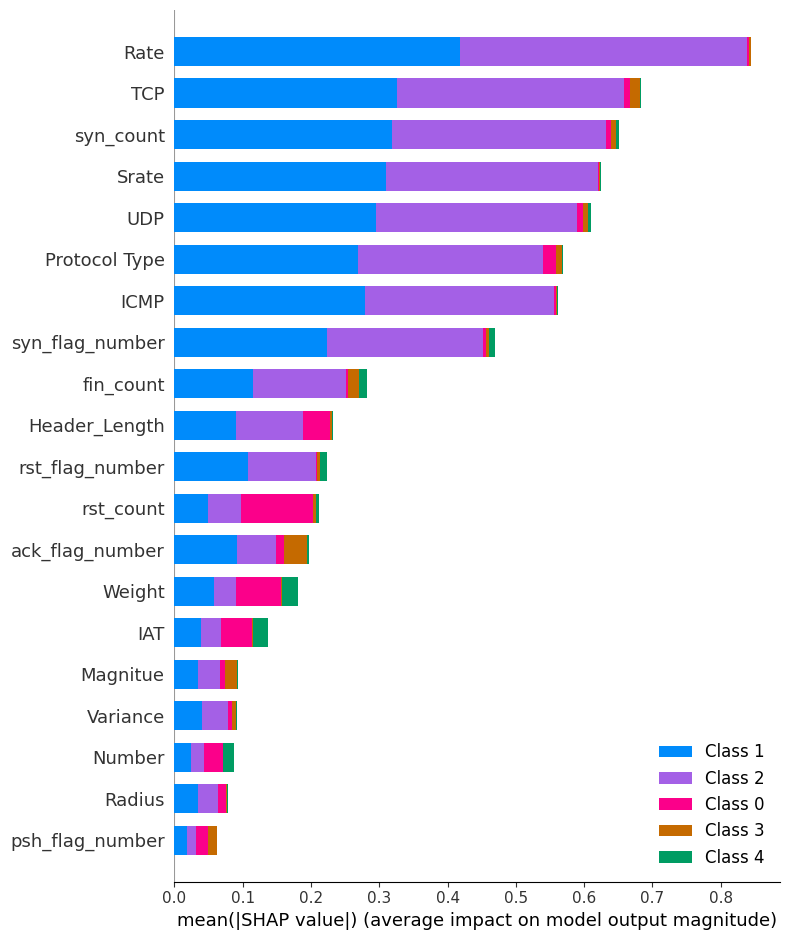

In [21]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names = feature_names,
    plot_type="bar"
)

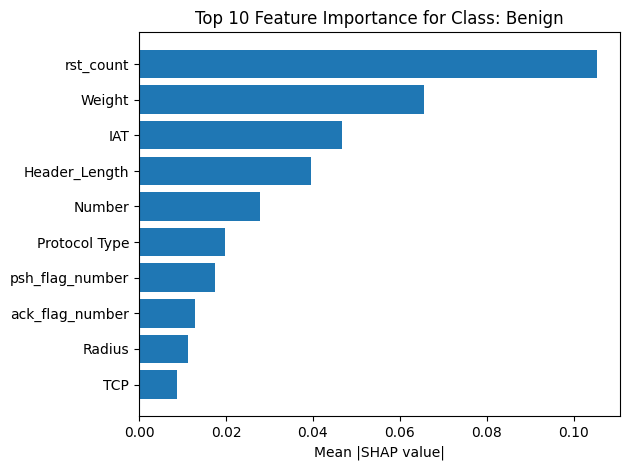

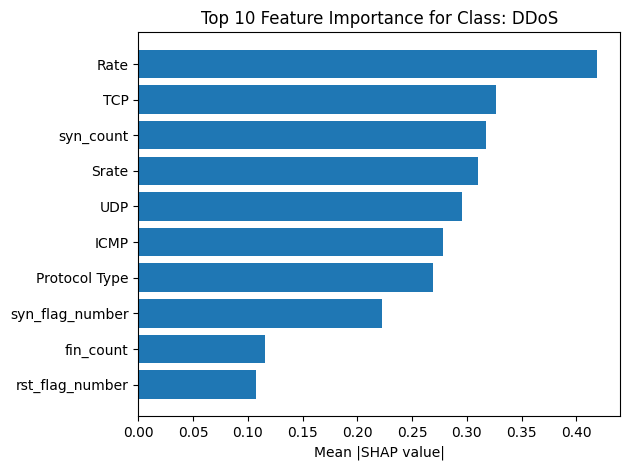

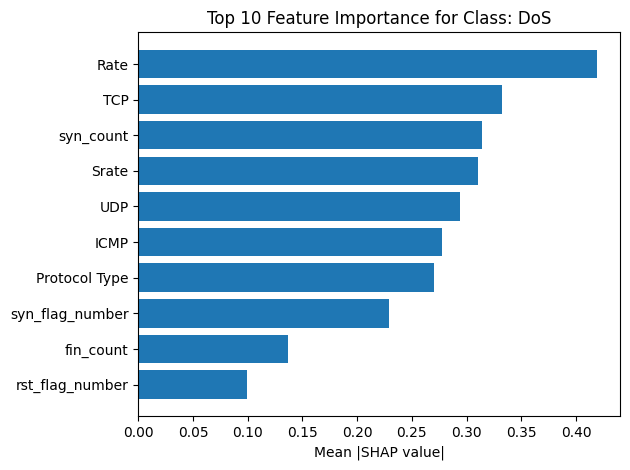

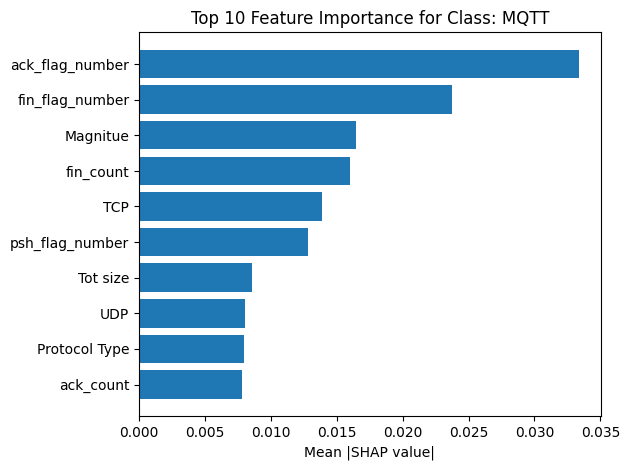

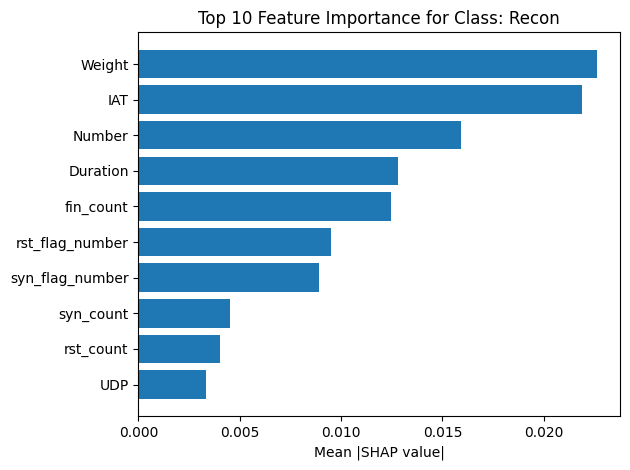

In [8]:
for i, class_name in enumerate(encoder.classes_):
    mean_abs = np.abs(shap_values[:, :, i]).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-10:]
    top_idx = top_idx[np.argsort(mean_abs[top_idx])]
    plt.figure()
    plt.barh(
        np.array(feature_names)[top_idx],
        mean_abs[top_idx]
    )
    
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top 10 Feature Importance for Class: {class_name}")
    plt.tight_layout()
    plt.show()

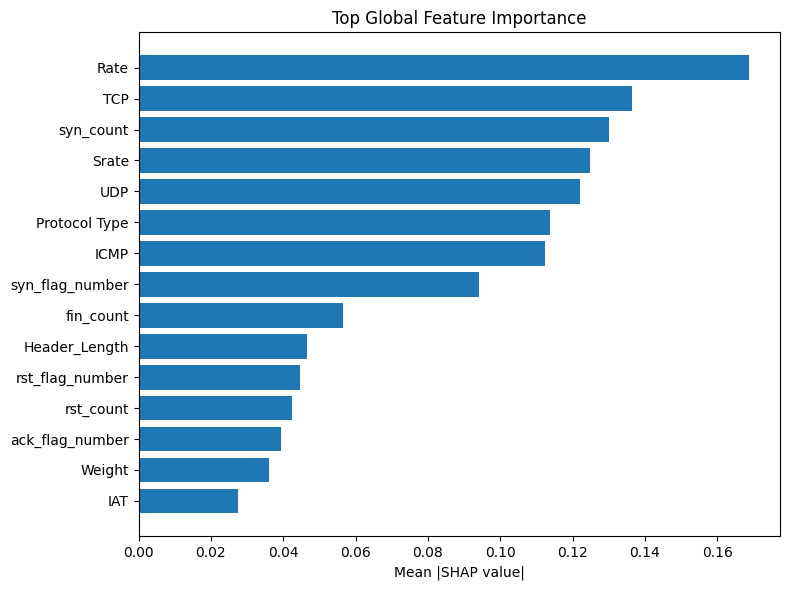

In [9]:
mean_abs_all = np.abs(shap_values).mean(axis=(0,2))

top_idx = np.argsort(mean_abs_all)[-15:]

plt.figure(figsize=(8,6))

plt.barh(
    np.array(feature_names)[top_idx],
    mean_abs_all[top_idx]
)

plt.xlabel("Mean |SHAP value|")
plt.title("Top Global Feature Importance")
plt.tight_layout()
plt.show()

In [16]:
sample_idx = 0
instance = X_sample[sample_idx]

In [17]:
pred_probs = model.predict(instance.reshape(1, -1))
pred_class = np.argmax(pred_probs)
print("Predicted class:", encoder.classes_[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted class: DDoS


In [18]:
base_value = explainer.expected_value[pred_class].numpy()

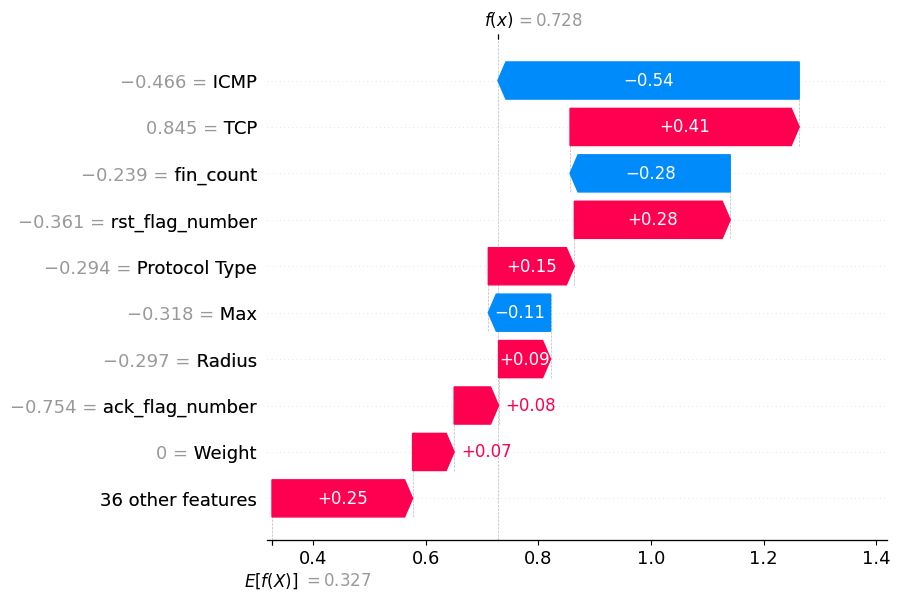

In [19]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx, :, pred_class],
        base_values=base_value,
        data=instance,
        feature_names=feature_names
    )
)